### Objetivvos E Entendimento Comum
O Naive Bayes Gaussiano é um algoritmo probabilístico baseado no Teorema de Bayes. Ele calcula a probabilidade de cada classe dado o conjunto de features, assumindo que todas as variáveis são independentes entre si, daí vem o seu nome naive (ingênuo), um exemplo de seu uso pode ser citado entre modelos de indentificação de mensagens spams. É o primeiro modelo real do projeto, escolhido por ser simples, rápido e por retornar probabilidades de pertencimento a cada classe, útil para gerar níveis de risco no app. Limitação conhecida: assume independência entre features, o que raramente é verdade em dados clínicos

### Bibliotecas e imports

In [9]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from utils_fc_notes import avaliar_modelo, plt_matriz_confusao

### Carregamento de Dados

Carregamos os quatro arquivos gerados pelo pré-processamento. O treino está balanceado pelo SMOTE (2.725/2.725) e normalizado. Já o teste está com a distribuição real e desbalanceada (682/123) para simular a entrada de dados no modelo.

In [10]:
X_train = pd.read_csv('../data/processed_data/X_train.csv')
X_test  = pd.read_csv('../data/processed_data/X_test.csv')
y_train = pd.read_csv('../data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print()
print('Distribuição y_train (balanceado com SMOTE):')
print(y_train.value_counts())
print()
print('Distribuição y_test (dados reais):')
print(y_test.value_counts())
print('  0 = Alive | 1 = Dead')

X_train: (5450, 14) | y_train: (5450,)
X_test:  (805, 14)  | y_test:  (805,)

Distribuição y_train (balanceado com SMOTE):
Status
0    2725
1    2725
Name: count, dtype: int64

Distribuição y_test (dados reais):
Status
0    682
1    123
Name: count, dtype: int64
  0 = Alive | 1 = Dead


### Treinamento dos Modelos


O GaussianNB é instanciado com parâmetros padrão e treinado nos dados de treino. Para cada feature, ele estima a média e a variância dentro de cada classe e usa isso para calcular as probabilidades de pertencimento a Alive ou Dead.

In [11]:
nb = GaussianNB()

nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print(f'Classes: {nb.classes_}')
print(f'Features utilizadas: {nb.n_features_in_}')

Classes: [0 1]
Features utilizadas: 14


### Métricas de Avaliação

Avaliamos o modelo com Acurácia, Precisão, Recall, F1-Score e AUC-ROC. O classification_report vai detalhar as métricas separadamente para cada classe.

In [12]:
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.762733
Precisão,0.304598
Recall,0.430894
F1-score,0.356902
AUC-ROC,0.626737


In [13]:
print(classification_report(y_test, y_pred, target_names=['Alive (0)', 'Dead (1)'], zero_division=0))

              precision    recall  f1-score   support

   Alive (0)       0.89      0.82      0.85       682
    Dead (1)       0.30      0.43      0.36       123

    accuracy                           0.76       805
   macro avg       0.60      0.63      0.61       805
weighted avg       0.80      0.76      0.78       805



### Matriz de Confusão
Visualiza a distribuição das previsões, especialmente os Falsos Negativos (Dead previsto como Alive), que representam o pior cenário clínico, que seria um paciente em risco não identificado pelo modelo.

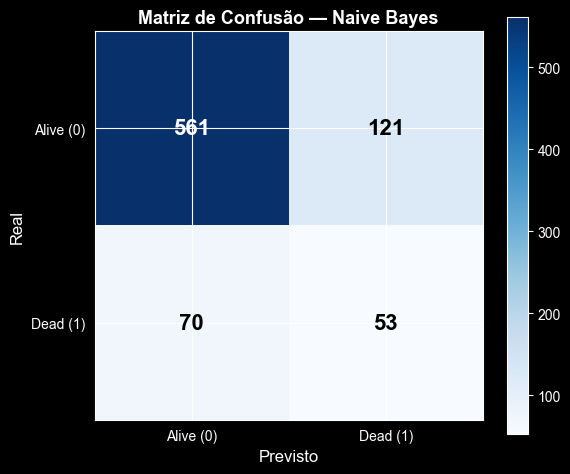


Verdadeiros Negativos: 561
Falsos Positivos: 121
Falsos Negativos: 70
Verdadeiros Positivos: 53


In [14]:
plt_matriz_confusao(
    y_test,
    y_pred,
    nome_modelo='Naive Bayes',
    salvar=True,
    caminho='../assets/charts_images/distributions/cm_naive_bayes.png'
)

### Features
O Naive Bayes não calcula importância de features diretamente. Por ideia analitica, pensamos em trazer a diferença absoluta entre as médias aprendidas pelo modelo para cada classe, quanto maior a diferença, mais aquela feature contribui para separar Alive de Dead na predição.

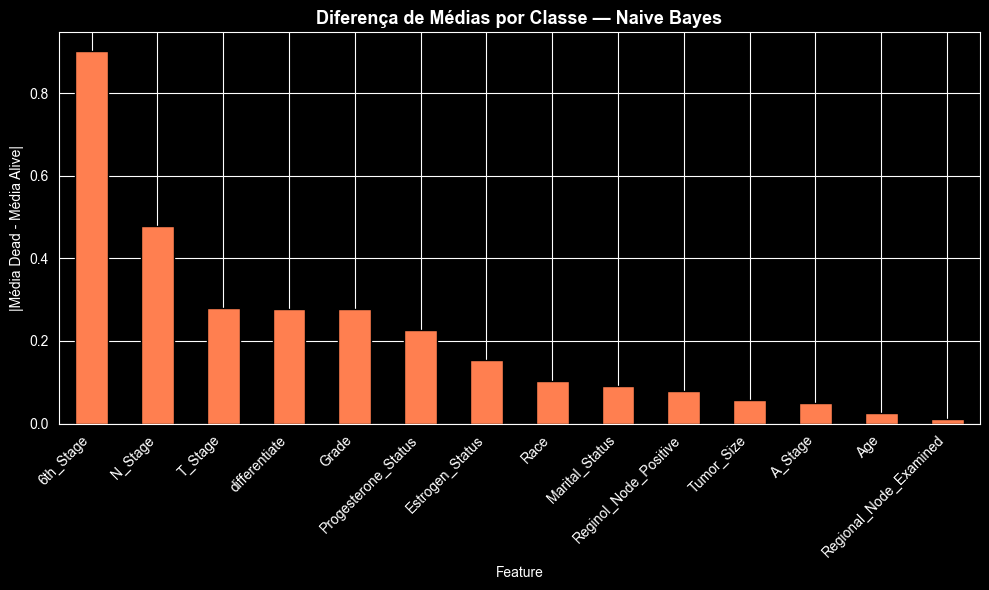

In [15]:
features = X_train.columns
medias_alive = nb.theta_[0]
medias_dead  = nb.theta_[1]

diferenca = np.abs(medias_dead - medias_alive)
fi_nb = pd.Series(diferenca, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fi_nb.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Diferença de Médias por Classe — Naive Bayes', fontsize=13, fontweight='bold')
ax.set_ylabel('|Média Dead - Média Alive|')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../assets/charts_images/distributions/feature_importance_naive_bayes.png', dpi=150)
plt.show()

### Hiperparametros

O único hiperparâmetro relevante para o Naive Bayes é o var_smoothing, que é um valor de suavização adicionado às variâncias para estabilidade numérica, evitando divisão por zero. Utilizamos GridSearchCV testando 7 valores de var_smoothing com scoring='recall' para priorizar a detecção de Dead (em analise de custo computacional ele rodou leve, por assim dizer). O resultado aponta o melhor valor e as métricas com o modelo otimizado são avaliadas logo em seguida.

In [16]:
param_grid = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Melhores parâmetros:', grid.best_params_)
print('Melhor Recall (CV):', grid.best_score_.round(4))

nb_best = grid.best_estimator_
y_pred = nb_best.predict(X_test)

Melhores parâmetros: {'var_smoothing': 1e-11}
Melhor Recall (CV): 0.5057


In [8]:
y_pred = grid.best_estimator_.predict(X_test)
avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.762733
Precisão,0.304598
Recall,0.430894
F1-score,0.356902
AUC-ROC,0.626737


### Salvamento do modelo

O melhor modelo encontrado pelo GridSearch é serializado com joblib em models/naive_bayes.joblib. Esse arquivo será carregado pelo backend FastAPI para fazer previsões em produção sem precisar retreinar.

In [17]:
os.makedirs('../models', exist_ok=True)

joblib.dump(nb_best, '../models/naive_bayes.joblib')

['../models/naive_bayes.joblib']